In [1]:
# Problem Statement
# 1- Does job type affect Average, after accounting for parental education?
# 2- Is there any relation between parents' education and the student's average score?
# 3- Do rural students have higher average score than urban students?
# 4- The students who has less number of family's members has higher grades?
# 5- What are the factors that affect student's average score?

In [2]:
# Setup and Data Loading 

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sn

In [4]:
df0 = pd.read_csv("C:\\Users\\ehabt\\Documents\\Building my portfolio\\student_data.csv")

In [5]:
# Data uderstading 

In [6]:
df0.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Average
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,8.67
5,GP,M,16,U,LE3,T,4,3,services,other,...,4,2,1,2,5,10,15,15,15,15.00
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,1,1,3,0,12,12,11,11.67
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,1,4,1,1,1,6,6,5,6,5.67
8,GP,M,15,U,LE3,A,3,2,services,other,...,2,2,1,1,1,0,16,18,19,17.67
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,1,1,1,5,0,14,15,15,14.67


In [7]:
# the parents' education is evaluated by ranking from 1 to 5 

In [8]:
df0.shape

(395, 34)

In [9]:
df0.columns = df0.columns.str.strip()

In [10]:
df0.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
Average       0
dtype: int64

In [11]:
# there are no null values in the data 

In [12]:
df0.dtypes

school         object
sex            object
age             int64
address        object
famsize        object
Pstatus        object
Medu            int64
Fedu            int64
Mjob           object
Fjob           object
reason         object
guardian       object
traveltime      int64
studytime       int64
failures        int64
schoolsup      object
famsup         object
paid           object
activities     object
nursery        object
higher         object
internet       object
romantic       object
famrel          int64
freetime        int64
goout           int64
Dalc            int64
Walc            int64
health          int64
absences        int64
G1              int64
G2              int64
G3              int64
Average       float64
dtype: object

In [13]:
# All data types are almost appropriate

In [14]:
df0.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Average
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000,19.330000


In [15]:
# The minimum age is 15 and the maximum is 22
# I noticed that maybe in the avsences column there is an outlier, so i need to check.

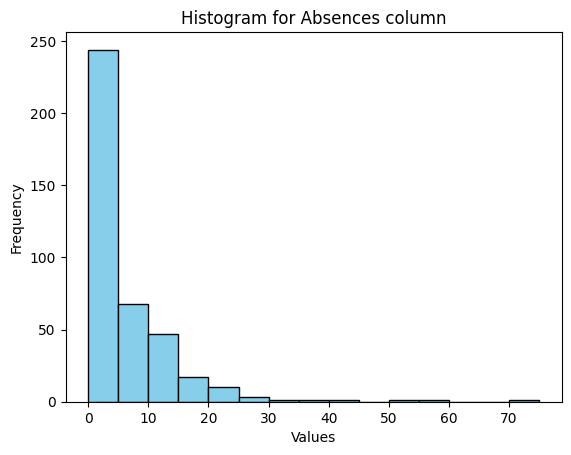

In [16]:
# Making an histogram for absences 
plt.hist(df0["absences"], bins = 15, color= "skyblue", edgecolor="Black")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Histogram for Absences column")
plt.show()

In [17]:
#that histogram shows that the absences column is skewed to the right which means that thier is an outlier in the data 
#I'll test if the travel time affects the absences maybe it's the reason of the outlier 
#so i'll use spearman's rho beacause the data in not normal, ordinal&quantitative and there are outliers 

In [18]:
spearman_corr= df0['absences'].corr(df0['traveltime'],method = "spearman")
print(spearman_corr)

-0.025060645540229663


In [19]:
#there is a weak negative relationship between absences and travel time 

In [20]:
# no the test is "Does job type affect Average, after accounting for parental education?"

In [21]:
# but first i need tho test the homogeneity of slopes 
from statsmodels.formula.api import ols
import statsmodels.api as sm
df0['Edu_Rank'] = df0['Medu']+df0['Fedu']
assumption_model = ols('Average ~ Edu_Rank * C(Mjob) + Edu_Rank * C(Fjob)', data = df0).fit()
assumption_table = sm.stats.anova_lm(assumption_model, typ=2)
print (assumption_table)

                       sum_sq     df         F    PR(>F)
C(Mjob)             93.756023    4.0  1.830874  0.122172
C(Fjob)             33.484199    4.0  0.653882  0.624452
Edu_Rank            80.655812    1.0  6.300209  0.012491
Edu_Rank:C(Mjob)    74.242310    4.0  1.449809  0.216971
Edu_Rank:C(Fjob)    80.009958    4.0  1.562440  0.183663
Residual          4826.385723  377.0       NaN       NaN


In [22]:
#the p-value in both is more than 0.05 which means slopes are equal across both Mjob and Fjob 
# so I'll apply Ancova


In [23]:
ancova_model = ols ( 'Average ~ Edu_Rank + C(Mjob) + C(Fjob) + C(Mjob):C(Fjob)', data = df0).fit()
ancova_table = sm.stats.anova_lm(ancova_model, typ=2)
print (ancova_table)

                      sum_sq     df         F    PR(>F)
C(Mjob)            43.482106    4.0  0.856042  0.490516
C(Fjob)            19.515702    4.0  0.384210  0.819926
C(Mjob):C(Fjob)   355.191397   16.0  1.748183  0.036554
Edu_Rank          106.419255    1.0  8.380399  0.004018
Residual         4698.478268  370.0       NaN       NaN


In [24]:
'''
It's not what job your mother has, or what job your father has. but it's the combination between both that made the effect 
it's the specific pairing of both jobs together that influences a student's average score, 
and this effect is real and independent of how educated the parents are.
'''

"\nIt's not what job your mother has, or what job your father has. but it's the combination between both that made the effect \nit's the specific pairing of both jobs together that influences a student's average score, \nand this effect is real and independent of how educated the parents are.\n"

In [25]:
# After ANCOVA — eta squared
ancova_table['eta_sq'] = ancova_table['sum_sq'] / ancova_table['sum_sq'].sum()
print(ancova_table[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_sq']])

                      sum_sq     df         F    PR(>F)    eta_sq
C(Mjob)            43.482106    4.0  0.856042  0.490516  0.008325
C(Fjob)            19.515702    4.0  0.384210  0.819926  0.003736
C(Mjob):C(Fjob)   355.191397   16.0  1.748183  0.036554  0.068004
Edu_Rank          106.419255    1.0  8.380399  0.004018  0.020375
Residual         4698.478268  370.0       NaN       NaN  0.899560


In [26]:
from scipy.stats import spearmanr
rho, p = spearmanr(df0['Edu_Rank'], df0['Average'])
print(rho)
print(p)

0.22648883060420222
5.459100347960495e-06


In [27]:
'''
Spearman's rho between parental education rank and student average score was ρ = 0.226, p < 0.001. 
The correlation is statistically significant but weak in strength,
meaning parental education has a real but limited association with student performance.
'''

"\nSpearman's rho between parental education rank and student average score was ρ = 0.226, p < 0.001. \nThe correlation is statistically significant but weak in strength,\nmeaning parental education has a real but limited association with student performance.\n"

In [28]:
# Now i'll examin the quesion"  Do rural students have higher average score than urban students?" 
# but first i need to test the normality of the average column grouped by the Rural and the Urban students 

In [29]:
# now we need to seperate the data 
df_r = df0[df0['address']=="R"]
df_u = df0[df0['address']=="U"]

# the number of the observations is less than 2000 so i'll apply shapiro test for the normality 
from scipy.stats import shapiro
stat, p = shapiro(df_u['Average'])
print("statistic for U:", stat)
print("P_value for U:", p)

stat, p = shapiro(df_r['Average'])
print("statistic for R:", stat)
print("P_value for R:", p)

statistic for U: 0.9914410460574306
P_value for U: 0.07217606314657758
statistic for R: 0.9864042445898075
P_value for R: 0.49175382953660546


In [30]:
# the data is normal but i need also to check the equality of the variances in the data 

In [31]:
from scipy.stats import levene 
stat, p = levene(df_u['Average'], df_r['Average'])

print("P_value = ", p)



P_value =  0.9263434528936187


In [32]:
# the variances are equal 
# once the data is normal and has equal variances so i'll apply the paramatric test t-test

In [33]:
from scipy.stats import ttest_ind
stat, p = ttest_ind(df_r['Average'], df_u['Average'], equal_var=True)

p_one_sided = p / 2 if stat > 0 else 1 - (p / 2)

print("t-stat:", stat)
print("one-sided p-value:", p_one_sided)

t-stat: -2.139045488785078
one-sided p-value: 0.9834761550084643


In [34]:
# the test shows that the average score to the rural students is higher than the urban students 

In [35]:
def cohen_d(g1, g2):
    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    return (g1.mean() - g2.mean()) / pooled_std

d = cohen_d(df_r['Average'], df_u['Average'])
print(f"Cohen's d = {d:.4f}")
print("Small effect" if abs(d) < 0.5 else "Medium effect" if abs(d) < 0.8 else "Large effect")

Cohen's d = -0.2578
Small effect


In [36]:
#the next assumption is "The students who has less number of family's members has higher grades?"

In [37]:
#normality check 
# data seperation 
df_L = df0[df0['famsize']=="LE3"]['Average']
df_G = df0[df0['famsize']=="GT3"]['Average']

stat,p =shapiro(df_L)
print ("Statistic for L = ", stat)
print ("P_Value for L = ", p )

stat,p =shapiro(df_G)
print ("Statistic for G = ", stat)
print ("P_Value for G = ", p)


Statistic for L =  0.9911796793901176
P_Value for L =  0.6783414016653042
Statistic for G =  0.9916572686708969
P_Value for G =  0.11308377836730915


In [38]:
#the data is normal 
# variance equality check 

stat, p = levene(df_L, df_G)
print ( "P_Value = " , p)

P_Value =  0.36014596731055243


In [39]:
# there is homogeneity of variances 
# one side t test
stat, p = ttest_ind(df_L,df_G, equal_var = True)
p_one_side = p /2 if stat > 0 else 1-(p / 2)

print ("P_Value = ",  p_one_side)

P_Value =  0.05066614886676524


In [40]:
 #t-test
d = cohen_d(df_L, df_G)
print(f"Cohen's d = {d:.4f}")
print("Small effect" if abs(d) < 0.5 else "Medium effect" if abs(d) < 0.8 else "Large effect")

Cohen's d = 0.1849
Small effect


In [41]:
# the average grade of the student who have less family members is greater the who have more famile members 
# then move on to the last question which is " What are the factors that affect student's average score?"
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# ── 1. Encode categorical variables ──────────────────────────────────────
# statsmodels handles C() for you in formulas, but let's also make dummies
# for the VIF check and LASSO (which needs a numeric matrix)
df = df0.copy()

# ── 2. VIF check — spot multicollinearity before model fitting ────────────
# Only numerical columns here; encode categoricals as dummies first
df_encoded = pd.get_dummies(
    df[['Medu', 'Fedu', 'address', 'Mjob', 'Fjob']],
    drop_first=True  # avoids dummy variable trap
)
df_encoded = df_encoded.astype(float)
df_encoded_const = sm.add_constant(df_encoded)

vif_data = pd.DataFrame({
    'Feature': df_encoded_const.columns,
    'VIF': [variance_inflation_factor(df_encoded_const.values, i)
            for i in range(df_encoded_const.shape[1])]
})
print(vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False))
# Rule of thumb: VIF > 5 → concern, > 10 → drop one of the correlated pair

# ── 3. Stepwise selection by AIC ─────────────────────────────────────────
# Forward stepwise: start empty, greedily add the predictor that lowers AIC most
def forward_stepwise_aic(df, response, candidates):
    selected = []
    remaining = list(candidates)
    best_aic = np.inf
    
    while remaining:
        aic_scores = {}
        for var in remaining:
            formula = f"{response} ~ {' + '.join(selected + [var])}" if selected \
                      else f"{response} ~ {var}"
            model = smf.ols(formula, data=df).fit()
            aic_scores[var] = model.aic
        
        best_var = min(aic_scores, key=aic_scores.get)
        
        if aic_scores[best_var] < best_aic:
            best_aic = aic_scores[best_var]
            selected.append(best_var)
            remaining.remove(best_var)
            print(f"  Added '{best_var}' → AIC = {best_aic:.2f}")
        else:
            print(f"  No improvement — stopping.")
            break
    
    return selected

candidates = ['Medu', 'Fedu', 'C(address)', 'C(Mjob)', 'C(Fjob)', 'Edu_Rank']
print("Forward stepwise selection:")
selected_vars = forward_stepwise_aic(df, 'Average', candidates)

final_formula = f"Average ~ {' + '.join(selected_vars)}"
print(f"\nFinal formula: {final_formula}")

# ── 4. Fit the final model ────────────────────────────────────────────────
model = smf.ols(final_formula, data=df).fit()
print(model.summary())


          Feature       VIF
9      Fjob_other  5.496446
10  Fjob_services  4.820877
7    Mjob_teacher  2.678257
1            Medu  2.526307
6   Mjob_services  2.509499
11   Fjob_teacher  2.474192
5      Mjob_other  2.433169
4     Mjob_health  1.994468
8     Fjob_health  1.928164
2            Fedu  1.865827
3       address_U  1.042010
Forward stepwise selection:
  Added 'Medu' → AIC = 2136.51
  Added 'C(address)' → AIC = 2136.04
  No improvement — stopping.

Final formula: Average ~ Medu + C(address)
                            OLS Regression Results                            
Dep. Variable:                Average   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     11.67
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.20e-05
Time:                        20:51:32   Log-Likelihood:                -1065.0
No. Observations:    

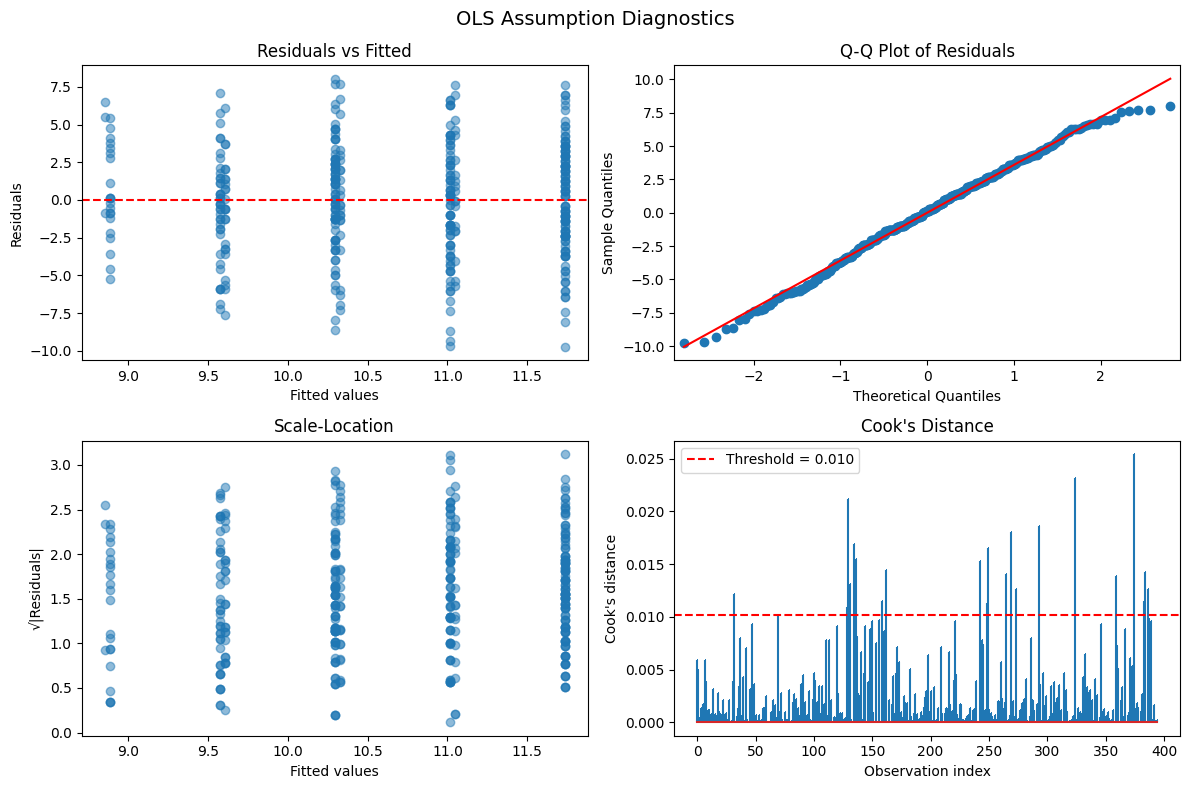


Breusch-Pagan test: stat=0.6663, p=0.7167
→ Homoscedasticity holds

Shapiro-Wilk on residuals: stat=0.9932, p=0.0723
→ Residuals are normal

LASSO best α: 0.1173

Non-zero LASSO coefficients (= selected variables):
          Feature  Coefficient
0            Medu     0.495301
3     Mjob_health     0.233688
5   Mjob_services     0.171716
10   Fjob_teacher     0.171410
2       address_U     0.163314
1            Fedu     0.106701
4      Mjob_other    -0.055461
8      Fjob_other    -0.006274


In [42]:
# ── 5. Check OLS assumptions ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('OLS Assumption Diagnostics', fontsize=14)

residuals = model.resid
fitted = model.fittedvalues

# 5a. Residuals vs fitted (linearity + homoscedasticity)
axes[0, 0].scatter(fitted, residuals, alpha=0.5)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set(xlabel='Fitted values', ylabel='Residuals',
               title='Residuals vs Fitted')

# 5b. Q-Q plot (normality of residuals)
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Residuals')

# 5c. Scale-location (homoscedasticity)
axes[1, 0].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5)
axes[1, 0].set(xlabel='Fitted values', ylabel='√|Residuals|',
               title='Scale-Location')

# 5d. Cook's distance (influential points)
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]
axes[1, 1].stem(range(len(cooks_d)), cooks_d, markerfmt=',')
axes[1, 1].axhline(4 / len(df), color='red', linestyle='--',
                   label=f'Threshold = {4/len(df):.3f}')
axes[1, 1].set(xlabel='Observation index', ylabel="Cook's distance",
               title="Cook's Distance")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 5e. Breusch-Pagan test for homoscedasticity
X_matrix = model.model.exog
bp_stat, bp_p, f_stat, f_p = het_breuschpagan(residuals, X_matrix)
print(f"\nBreusch-Pagan test: stat={bp_stat:.4f}, p={bp_p:.4f}")
print("→ Homoscedasticity holds" if bp_p > 0.05 else "→ Heteroscedasticity detected — consider WLS or robust SE")

# 5f. Shapiro-Wilk on residuals
stat, p = shapiro(residuals)
print(f"\nShapiro-Wilk on residuals: stat={stat:.4f}, p={p:.4f}")
print("→ Residuals are normal" if p > 0.05 else "→ Non-normal residuals — check for outliers or skew")

# ── 6. LASSO as an alternative (cross-validated) ─────────────────────────
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

X = df_encoded.copy()
y = df['Average']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)
print(f"\nLASSO best α: {lasso.alpha_:.4f}")

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
}).query('Coefficient != 0').sort_values('Coefficient', key=abs, ascending=False)
print("\nNon-zero LASSO coefficients (= selected variables):")
print(coef_df)

In [43]:
# so those are the factors that affect the student's average grade

In [45]:
# 1. The cleaned dataset → for building visuals
df0.to_csv('student_data_clean.csv', index=False)
